<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/31_outlier_detection_using_percentiles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/weight-height.csv')

In [8]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Density'>

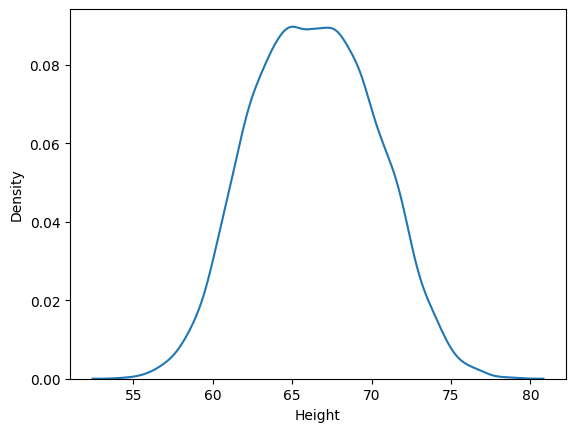

In [11]:
sns.kdeplot(df['Height'])

<Axes: ylabel='Height'>

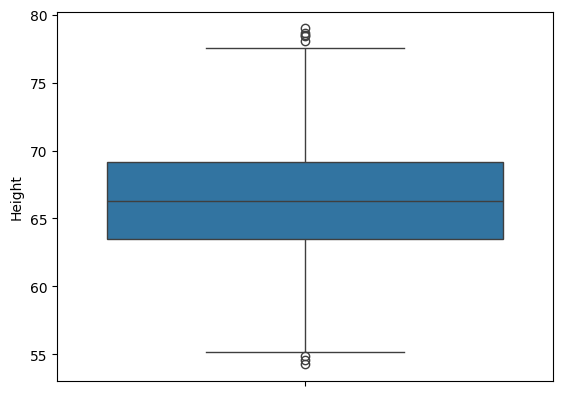

In [12]:
sns.boxplot(df['Height'])

In [13]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [14]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [15]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [16]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


/tmp/ipykernel_853/1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

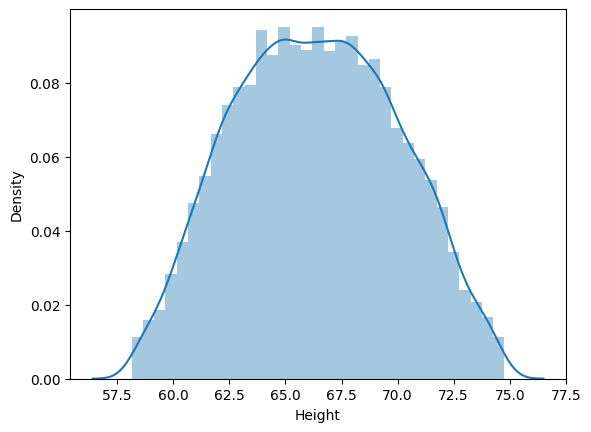

In [17]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

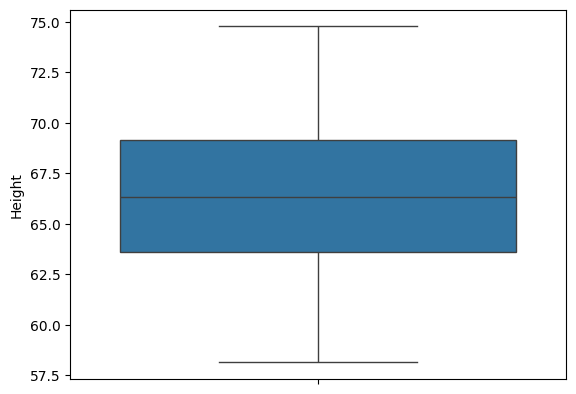

In [18]:
sns.boxplot(new_df['Height'])

In [19]:
# Capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [20]:
df.shape

(10000, 3)

<Axes: ylabel='Height'>

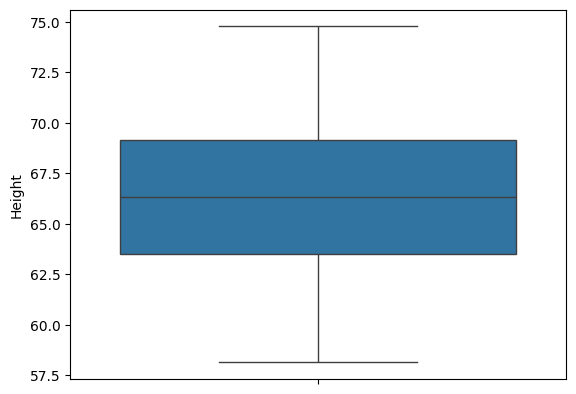

In [21]:
sns.boxplot(df['Height'])

<Axes: xlabel='Height', ylabel='Density'>

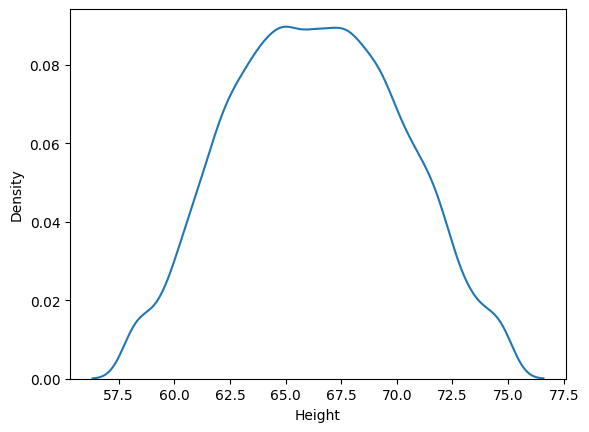

In [23]:
sns.kdeplot(df['Height'])